In [62]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

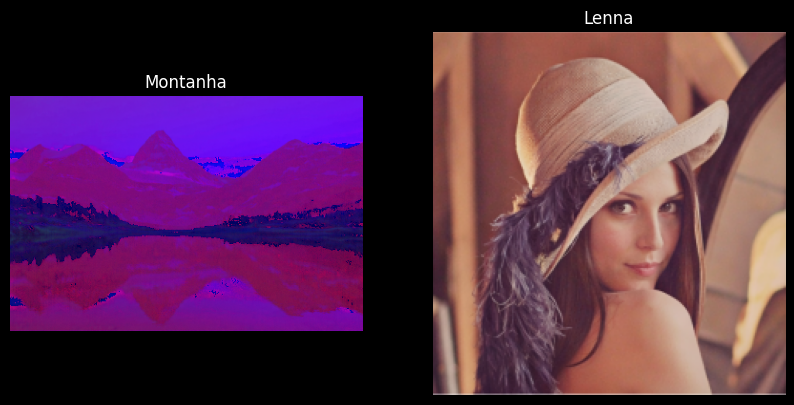

In [63]:
#carregar imagens
montanha_bgr = cv2.imread('data/montanha.png')
lenna_bgr = cv2.imread('data/lenna.png')

#converter para HSV
montanha_hsv = cv2.cvtColor(montanha_bgr, cv2.COLOR_BGR2HSV)
lenna_rgb = cv2.cvtColor(lenna_bgr, cv2.COLOR_BGR2RGB)

#exibir imagens originais
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(montanha_hsv)
plt.title('Montanha')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lenna_rgb)
plt.title('Lenna')
plt.axis('off')
plt.show()

In [64]:
#aplicar o stretching
montanha_out_hsv = montanha_hsv.astype(np.float32)
montanha_out_hsv = (montanha_out_hsv[:, :, 2] - montanha_out_hsv[:, :, 2].min()) * (
        255 / (montanha_out_hsv[:, :, 2].max() - montanha_out_hsv[:, :, 2].min()))

np.clip(montanha_out_hsv, 0, 255, out=montanha_out_hsv)

montanha_out_hsv = montanha_out_hsv.astype(np.uint8)

montanha_hsv = cv2.cvtColor(montanha_bgr, cv2.COLOR_BGR2HSV)

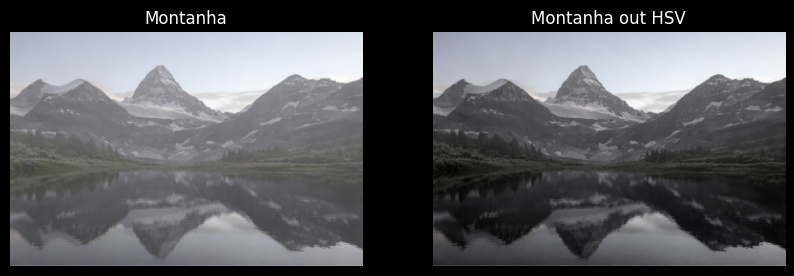

In [65]:
#voltando o V para o HSV
montanha_hsv[:, :, 2] = montanha_out_hsv

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(montanha_bgr, cv2.COLOR_BGR2RGB))
plt.title('Montanha')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(montanha_hsv, cv2.COLOR_HSV2RGB))
plt.title('Montanha out HSV')
plt.axis('off')
plt.show()

In [66]:
#Fazendo o mesmo mas em RGB

motanha_rgb = cv2.cvtColor(montanha_bgr, cv2.COLOR_BGR2RGB)

montanha_out_rgb = motanha_rgb.astype(np.float32)
montanha_out_R = montanha_out_rgb[: ,:, 0]
montanha_out_G = montanha_out_rgb[: ,:, 1]
montanha_out_B = montanha_out_rgb[: ,:, 2]

montanha_out_R = (montanha_out_R - montanha_out_R.min()) * (255/(montanha_out_R.max() - montanha_out_R.min()))
montanha_out_G = (montanha_out_G - montanha_out_G.min()) * (255/(montanha_out_G.max() - montanha_out_G.min()))
montanha_out_B = (montanha_out_B - montanha_out_B.min()) * (255/(montanha_out_B.max() - montanha_out_B.min()))

montanha_out_rgb = np.dstack([montanha_out_R, montanha_out_G, montanha_out_B])
np.clip(montanha_out_rgb, 0, 255, out=montanha_out_rgb)
montanha_out_rgb = montanha_out_rgb.astype(np.uint8)

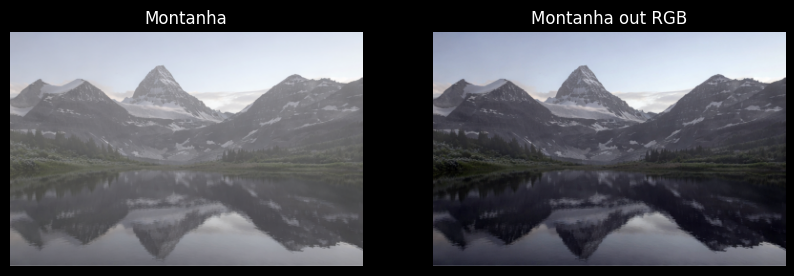

In [67]:
#mostrando resultados em RGB
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(motanha_rgb)
plt.title('Montanha')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(montanha_out_rgb)
plt.title('Montanha out RGB')
plt.axis('off')
plt.show()

In [68]:
#Clipping de contraste

def clip_contraste(imagem_rgb, p_min=2,p_max=98):
    imagem_rgb = imagem_rgb.astype(np.float32)

    canal_r = imagem_rgb[:, :, 0].copy()
    canal_g = imagem_rgb[:, :, 1].copy()
    canal_b = imagem_rgb[:, :, 2].copy()

    r_pmin = np.percentile(canal_r, p_min)
    r_pmax = np.percentile(canal_r, p_max)
    g_pmin = np.percentile(canal_g, p_min)
    g_pmax = np.percentile(canal_g, p_max)
    b_pmin = np.percentile(canal_b, p_min)
    b_pmax = np.percentile(canal_b, p_max)

    np.clip(canal_r,r_pmin,r_pmax,out=canal_r)
    np.clip(canal_g,g_pmin,g_pmax,out=canal_g)
    np.clip(canal_b,b_pmin,b_pmax,out=canal_b)

    canal_r_normalizado = (canal_r - r_pmin) * (255 / (r_pmax - r_pmin + np.finfo(np.float32).eps))
    canal_g_normalizado = (canal_g - g_pmin) * (255 / (g_pmax - g_pmin + np.finfo(np.float32).eps))
    canal_b_normalizado = (canal_b - b_pmin) * (255 / (b_pmax - b_pmin + np.finfo(np.float32).eps))

    np.clip(canal_r_normalizado, 0, 255, out=canal_r_normalizado)
    np.clip(canal_g_normalizado, 0, 255, out=canal_g_normalizado)
    np.clip(canal_b_normalizado, 0, 255, out=canal_b_normalizado)

    canal_r_normalizado = canal_r_normalizado.astype(np.uint8)
    canal_g_normalizado = canal_g_normalizado.astype(np.uint8)
    canal_b_normalizado = canal_b_normalizado.astype(np.uint8)

    imagem_rgb = np.dstack([canal_r_normalizado, canal_g_normalizado, canal_b_normalizado])

    return imagem_rgb


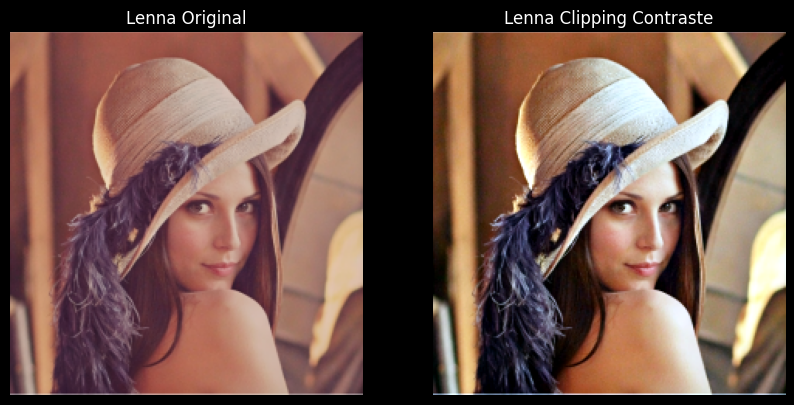

In [69]:
imagem = clip_contraste(lenna_rgb)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lenna_rgb)
plt.title('Lenna Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagem)
plt.title('Lenna Clipping Contraste')
plt.axis('off')
plt.show()

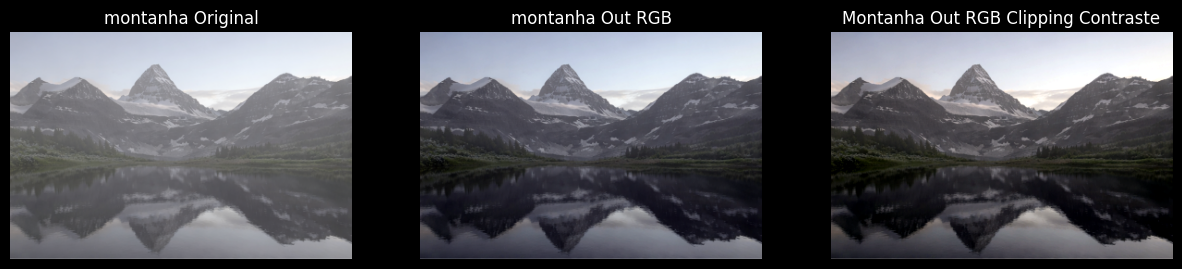

In [70]:
p_min = 2
p_max = 98
imagem = clip_contraste(montanha_out_rgb,p_min,p_max)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(motanha_rgb)
plt.title('montanha Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(montanha_out_rgb)
plt.title('montanha Out RGB')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(imagem)
plt.title('Montanha Out RGB Clipping Contraste')
plt.axis('off')
plt.show()

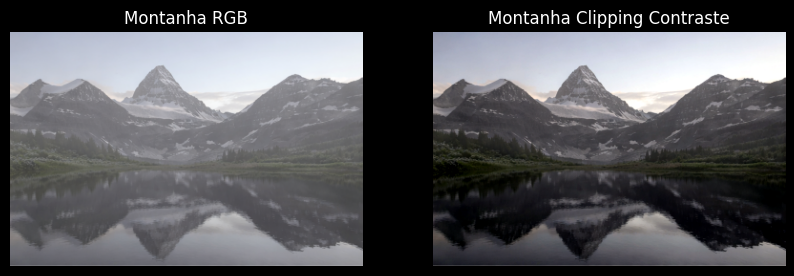

In [71]:
img = clip_contraste(motanha_rgb, p_min=2, p_max=98)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(motanha_rgb)
plt.title('Montanha RGB')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.title('Montanha Clipping Contraste')
plt.axis('off')
plt.show()